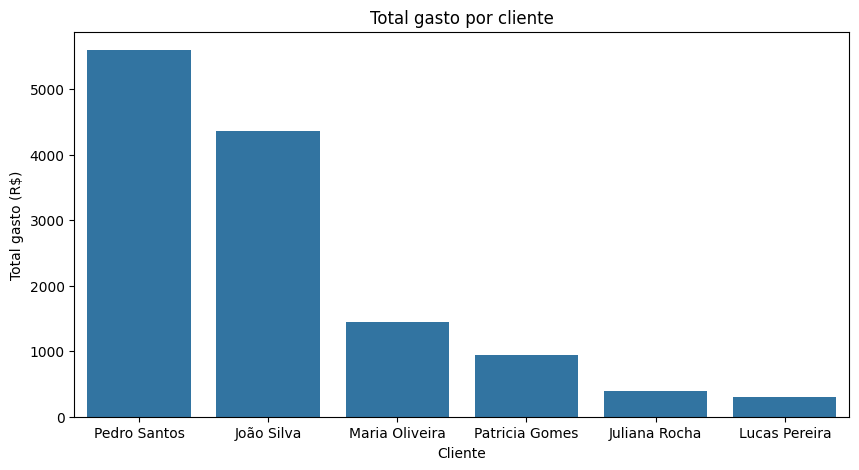

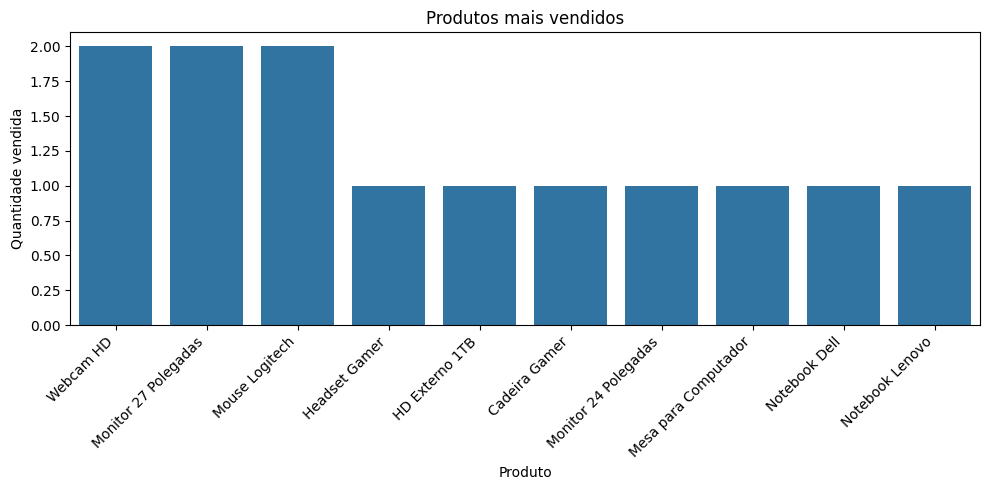

In [1]:
# 1. imports
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv()

# 2. conexão com o banco
engine = create_engine(
    'mysql+pymysql://root@localhost/cadastro_clientes',
    connect_args={'password': 'Alpaca123@'}
)

# 3. leitura das tabelas
df_clientes = pd.read_sql('SELECT * FROM clientes', engine)
df_pedidos = pd.read_sql('SELECT * FROM pedidos', engine)
df_pedido_produto = pd.read_sql('SELECT * FROM pedido_produto', engine)
df_produtos = pd.read_sql('SELECT * FROM produtos', engine)

# 4. análise 1 — total gasto por cliente
df = pd.merge(df_clientes, df_pedidos, left_on='id', right_on='idcliente')
df = pd.merge(df, df_pedido_produto, on='idpedido')
df = pd.merge(df, df_produtos, on='idproduto')

df['total'] = df['quantidade'] * df['preco']
resultado = df.groupby('nome_x')['total'].sum().reset_index()
resultado.columns = ['cliente', 'total_gasto']
resultado = resultado.sort_values('total_gasto', ascending=False)

# análise 2 — produto mais vendido
resultado2 = pd.merge(df_pedido_produto, df_produtos, on='idproduto')
resultado2 = resultado2.groupby('nome')['quantidade'].sum().reset_index()
resultado2.columns = ['produto', 'total_vendido']
resultado2 = resultado2.sort_values('total_vendido', ascending=False).reset_index(drop=True)

# análise 3 — produtos nunca vendidos
resultado3 = pd.merge(df_produtos, df_pedido_produto, on='idproduto', how='left')
resultado3 = resultado3[resultado3['idpedido'].isnull()]
resultado3 = resultado3[['nome']]

# 5. gráficos
plt.figure(figsize=(10, 5))
sns.barplot(data=resultado, x='cliente', y='total_gasto')
plt.title('Total gasto por cliente')
plt.xlabel('Cliente')
plt.ylabel('Total gasto (R$)')
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=resultado2.head(10), x='produto', y='total_vendido')
plt.title('Produtos mais vendidos')
plt.xlabel('Produto')
plt.ylabel('Quantidade vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()